# 🧠 APVC – Desafio 1
## Classificação de Imagens de Roupas com Redes Neuronais Clássicas

### 👥 Grupo G11
- **Bernardo Coelho**, nº 98445  
- **Rafael Alexandre Dias Andorinha**, nº 131000  
- **Nuno Martins**, nº 98863  
- **Pedro Fonte Santa**, nº 105306  

---

📅 **Data de entrega:** 09 de março  
📊 **Objetivo:** Desenvolver modelos de rede neuronal para classificação multiclasse e binária no dataset *FASHION_MNIST*, avaliando desempenho e no final comparar as duas abordagens.

---

# 📌 Parte 1:

In [13]:
# Imports
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import accuracy_score

In [2]:
# Constantes - dimensão das imagens
IMG_HEIGHT = 28
IMG_WIDTH = 28

# Constantes - labels/classes
LABELS = ["T-Shirt/Top",
          "Trouser",
          "Pullover",
          "Dress",
          "Coat",
          "Sandal",
          "Shirt",
          "Sneaker",
          "Bag",
          "Boot"]
N_CLASSES = 10

In [3]:
# Carregar o dataset FASHION_MNIST
dataset = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = dataset.load_data()

# Normalização
x_train = x_train / 255.0
x_test = x_test / 255.0

print(f"Número de amostras no training set original: {x_train.shape[0]}")
print(f"Número de amostras no test set original: {x_test.shape[0]}")
print("Não esquecer que se pretende também gerar um validation set!")

Número de amostras no training set original: 60000
Número de amostras no test set original: 10000
Não esquecer que se pretende também gerar um validation set!


In [4]:
# Transformar vetor das labels numa matriz one-hot - adequado para a Parte 1 (multiclasse)
y_train = keras.utils.to_categorical(y_train, N_CLASSES)
y_test = keras.utils.to_categorical(y_test, N_CLASSES)

### a) Obter um conjunto de validação

#### Dica para perceber melhor o conceito:
**A validação aparece para dizer: "Ok, já estudaste, mas e se eu te mostrar perguntas novas que não estavam exatamente no teu caderno de apontamentos? Consegues acertar?"**

In [5]:
# Dividir o conjunto de treino original em treino e validação (80% treino, 20% validação)
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

# Verificar as dimensões dos novos conjuntos
print(f"Número de amostras no treino: {x_train.shape[0]}")
print(f"Número de amostras na validação: {x_val.shape[0]}")

Número de amostras no treino: 48000
Número de amostras na validação: 12000


### b) Construir o modelo

In [6]:
# Construir o modelo de rede neuronal sequencial
model = keras.Sequential()

# Primeira camada densa (camada oculta)
model.add(layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH)))  # Achata a imagem 28x28 em um vetor 784
model.add(layers.Dense(128, activation='relu'))  # Camada densa com 128 neurônios e ReLU

# Segunda camada densa
model.add(layers.Dense(64, activation='relu'))  # Camada densa com 64 neurônios e ReLU

# Camada de saída (10 classes, com softmax)
model.add(layers.Dense(N_CLASSES, activation='softmax'))  # 10 neurônios para 10 classes e softmax

# Resumo do modelo
model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### c) Compilar a rede

In [7]:
# Compilar o modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### d) Treinar o modelo (máximo 50 épocas + callbacks)

**NOTA: Sempre que corrermos o modelo se for encontrada uma configuração de pesos melhor o ficheiro (best_model.weights.h5) é subscrito, caso contrário o ficheiro mantem-se o mesmo** 

In [ ]:
# Definir o callback para guardar o melhor modelo
BEST_MODEL_CHECKPOINT = keras.callbacks.ModelCheckpoint(
    filepath="tmp/best_model.weights.h5",      # Caminho para guardar os pesos do melhor modelo
    save_weights_only=True,                     # Guarda apenas os pesos (não o modelo completo)
    monitor='val_loss',                         # Monitoriza a perda no conjunto de validação
    mode='min',                                # Guarda o modelo quando a perda for mínima
    save_best_only=True)                       # Guarda apenas o melhor modelo

# Definir o callback para parar o treino precocemente
EARLY_STOPPING = keras.callbacks.EarlyStopping(
    monitor='val_loss',                        # Monitoriza a perda no conjunto de validação
    patience=5)                                # Número de épocas sem melhoria para parar o treino

# Treinar o modelo com callbacks
history = model.fit(
    x_train, y_train,                          # Dados de treino
    epochs=50,                                 # Número máximo de épocas
    batch_size=32,                             # Tamanho do batch (ajustável, mas 32 é comum)
    validation_data=(x_val, y_val),            # Dados de validação
    callbacks=[BEST_MODEL_CHECKPOINT, EARLY_STOPPING],  # Callbacks para monitorização
    verbose=2                                   # Mostrar informações de cada época durante o treino
)

Epoch 1/50
1500/1500 - 8s - 6ms/step - accuracy: 0.8163 - loss: 0.5190 - val_accuracy: 0.8569 - val_loss: 0.4054
Epoch 2/50
1500/1500 - 7s - 5ms/step - accuracy: 0.8608 - loss: 0.3828 - val_accuracy: 0.8675 - val_loss: 0.3638
Epoch 3/50
1500/1500 - 9s - 6ms/step - accuracy: 0.8727 - loss: 0.3442 - val_accuracy: 0.8648 - val_loss: 0.3593
Epoch 4/50
1500/1500 - 6s - 4ms/step - accuracy: 0.8835 - loss: 0.3171 - val_accuracy: 0.8791 - val_loss: 0.3346
Epoch 5/50
1500/1500 - 6s - 4ms/step - accuracy: 0.8882 - loss: 0.2995 - val_accuracy: 0.8753 - val_loss: 0.3365
Epoch 6/50
1500/1500 - 6s - 4ms/step - accuracy: 0.8940 - loss: 0.2824 - val_accuracy: 0.8770 - val_loss: 0.3468
Epoch 7/50
1500/1500 - 6s - 4ms/step - accuracy: 0.8980 - loss: 0.2722 - val_accuracy: 0.8784 - val_loss: 0.3460
Epoch 8/50
1500/1500 - 6s - 4ms/step - accuracy: 0.9017 - loss: 0.2597 - val_accuracy: 0.8807 - val_loss: 0.3372
Epoch 9/50
1500/1500 - 6s - 4ms/step - accuracy: 0.9052 - loss: 0.2519 - val_accuracy: 0.8852 - 

### e) Gerar gráficos da evolução do treino

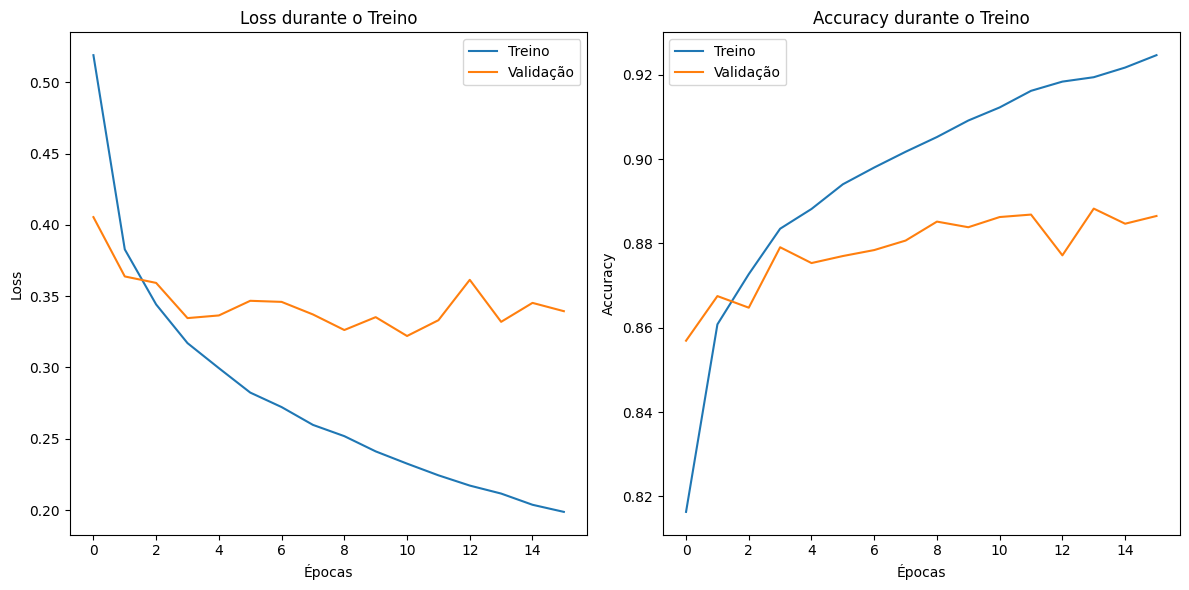

In [ ]:
# Carregar os pesos do melhor modelo
model.load_weights("tmp/best_model.weights.h5")

# Históricos de treino
history = model.history.history  # Obtendo o histórico do modelo

# Mostrar a perda de treino e validação
plt.figure(figsize=(12, 6))

# Loss de treino e validação
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Treino')
plt.plot(history['val_loss'], label='Validação')
plt.title('Loss durante o Treino')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Accuracy de treino e validação
plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Treino')
plt.plot(history['val_accuracy'], label='Validação')
plt.title('Accuracy durante o Treino')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Exibir os gráficos
plt.tight_layout()
plt.show()

### f) Calcular taxa de acertos no conjunto de teste

In [11]:
# Avaliar o modelo no conjunto de teste
test_loss, test_accuracy = model.evaluate(x_test, y_test)

# Mostrar a taxa de acertos no conjunto de teste
print(f'Taxa de acertos no conjunto de teste: {test_accuracy * 100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8808 - loss: 0.3433
Taxa de acertos no conjunto de teste: 88.07%


### g) Matriz de confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<Figure size 1200x1000 with 0 Axes>

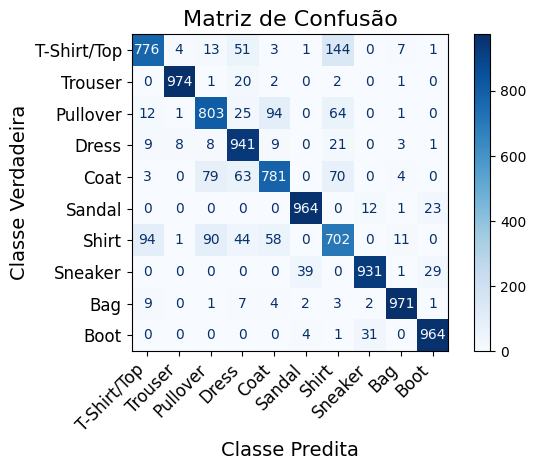

In [ ]:
# Fazer predições no conjunto de teste
y_pred = model.predict(x_test)

# Converter as predições para as classes (usando argmax para obter a classe com maior probabilidade)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Gerar a matriz de confusão
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plotar a matriz de confusão
plt.figure(figsize=(12, 10)) 

disp = ConfusionMatrixDisplay(conf_matrix, display_labels=LABELS)
disp.plot(cmap=plt.cm.Blues)

# Rotacionar as labels do eixo X para melhor visualização
plt.xticks(rotation=45, ha='right', fontsize=12)  # Ajusta rotação e alinhamento
plt.yticks(rotation=0, fontsize=12)  # Alinha as labels do eixo Y

plt.title("Matriz de Confusão", fontsize=16)
plt.xlabel('Classe Predita', fontsize=14)
plt.ylabel('Classe Verdadeira', fontsize=14)
plt.tight_layout()  # Ajusta automaticamente o layout para evitar sobreposição

plt.show()

**A partir da análise da matriz de confusão, podemos observar de imediato que o modelo apresenta uma tendência significativa para confundir as classes **T-Shirt/Top** com **Shirt**. Este tipo de erro ocorre frequentemente, refletindo uma sobreposição nas características visuais entre essas duas categorias. Da mesma forma, o modelo também demonstra uma certa confusão entre as classes **Pullover** e **Coat**, embora essa confusão seja menos pronunciada.**

**É importante notar que, embora o modelo cometa erros, ele tende a confundir as classes mais frequentemente em pares específicos, como T-Shirts/Top com Shirts e Pullovers com Coats, sendo que os erros inversos (ou seja, quando as classes estão trocadas na direção oposta) são observados, mas em menor escala. Este comportamento sugere que, apesar de existirem padrões visuais que permitem distinguir as classes, existem também características comuns que levam a essas confusões, apontando áreas para melhorias no modelo.**

# 📌 Parte 3:

### Comparar classificações de ambos os modelos anteriores 
#### (predições multi-classe binarizadas vs. predições binárias diretas)

In [15]:
# ✅ 1. Abordagem multiclasse com binarização

model.load_weights("tmp/best_model.weights.h5")

# Fazer predições no conjunto de teste original (multiclasse)
predictions_multiclass = model.predict(x_test)
pred_classes_multiclass = np.argmax(predictions_multiclass, axis=1)

# Converter as labels reais (y_test) para binário: 1 para Vestuário, 0 para Calçado/Malas
y_test_classes = np.argmax(y_test, axis=1)
y_test_binary = np.isin(y_test_classes, [0, 1, 2, 3, 4, 6]).astype(int)

# Converter as predições para binário
pred_binary_multiclass = np.isin(pred_classes_multiclass, [0, 1, 2, 3, 4, 6]).astype(int)

# Calcular acurácia da abordagem multiclasse com binarização
accuracy_multiclass_binary = accuracy_score(y_test_binary, pred_binary_multiclass)
print(f"Accuracy da rede multiclasse com binarização: {accuracy_multiclass_binary:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy da rede multiclasse com binarização: 0.9945
